# Created using following the tutorial https://www.youtube.com/watch?v=G_yqv0Vj3ug

In [1]:
%matplotlib widget
import hyperspy.api as hs
import tkinter as tk
from tkinter import filedialog

In [21]:
# Create a function to select a file
def load_file():
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    file_path = filedialog.askopenfilename(
        title="Select a .hspy file",
        filetypes=[("All Files", "*.*"),("Hyperspy Files", "*.hspy") ]
    )

    if file_path:  # If a file is selected
        print("Selected file:", file_path)
        data = hs.load(file_path)
        print(data)
        return data  # Return loaded data

    return None  # If no file is selected

# Load the selected file
data = load_file()

Selected file: C:/Users/b1104371/OneDrive - Universität Salzburg/Research/Electrolyte variation/Charecterizations/TEM/250423_LiS-SOC100/PreCam/XF416R_singleEELS_0001.prz
WARNING | Hyperspy | `signal_type='EELS'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:744)
<Signal1D, title: XF416R_singleEELS, dimensions: (|4096)>


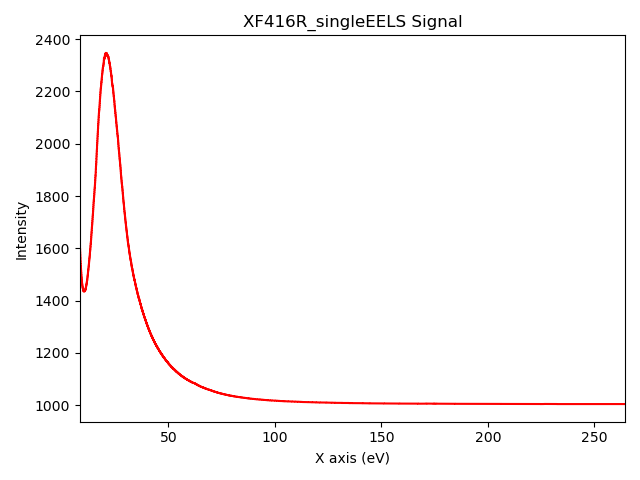

In [22]:
data.plot() # Plot the raw data 

# Apply a manual shift for correct alignment 

WARNING | Hyperspy | `signal_type='EELS'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:744)
WARNING | Hyperspy | `signal_type='EELS'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:744)
[########################################] | 100% Completed | 104.39 ms


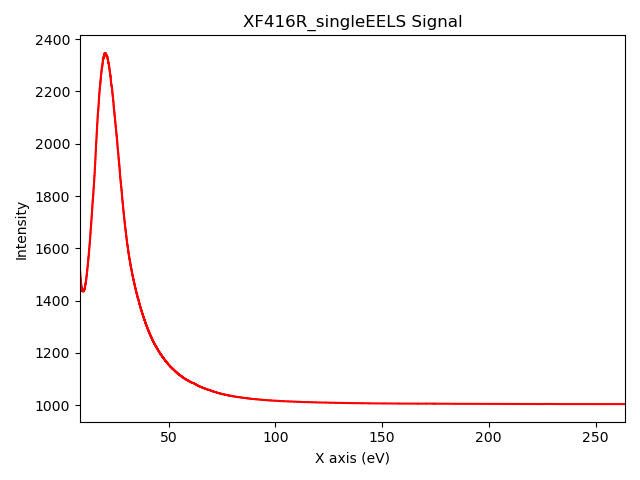

In [26]:
def align_data(input_file, shift):
    data_corrected = input_file.deepcopy()
    import numpy as np

    # Shift value wrapped in a NumPy array
    shift_array = np.array([shift])

    # Apply the shift
    # Apply shift and expand the data to retain all information
    data_corrected.shift1D(shift_array, interpolation_method = 'linear', expand= False)
    data_corrected.plot() # Plot the shifted data
    return data_corrected

data_corrected = align_data(data, -0.5) # Shift the data 

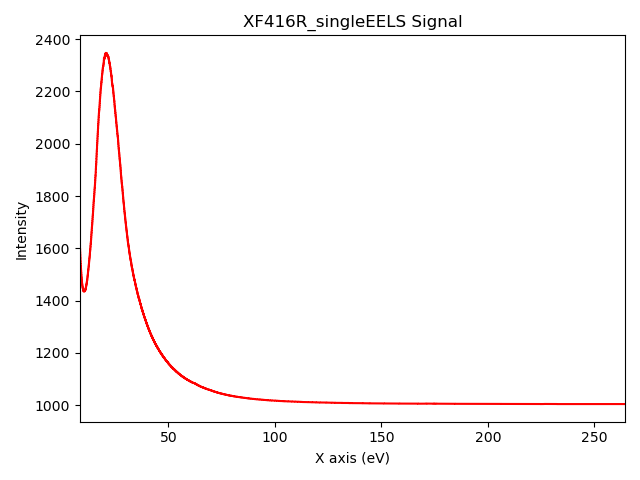

c:\Users\b1104371\AppData\Local\anaconda3\Lib\site-packages\jupyter_client\session.py:718: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


ModuleNotFoundError: No module named 'pyface.action.schema'

In [24]:
data_manual_calibration = data.deepcopy()
data_manual_calibration.calibrate()

# Smooth the data 

Note: you may need to restart the kernel to use updated packages.


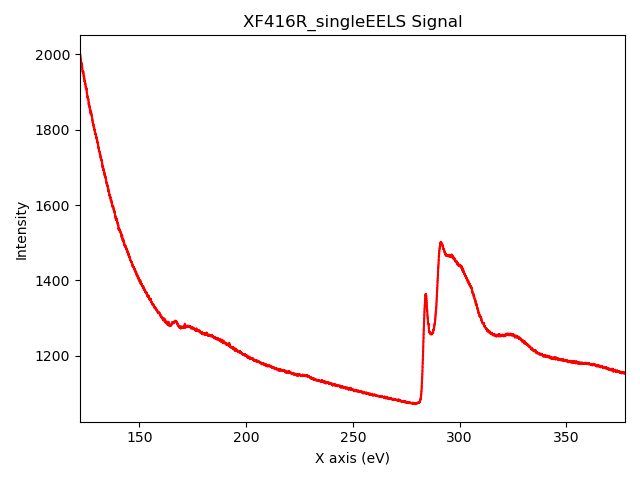

WARNING | Hyperspy | `signal_type='EELS'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:744)


ModuleNotFoundError: No module named 'pyface.action.schema'

ValueError: Axis limits cannot be NaN or Inf

ValueError: Axis limits cannot be NaN or Inf

ValueError: Axis limits cannot be NaN or Inf

In [14]:
# Ensure the required package and dependencies are installed
%pip install pyface traits

# Plot and smooth the data
data_corrected.plot()
data_corrected.smooth_savitzky_golay()

# Data cropping 

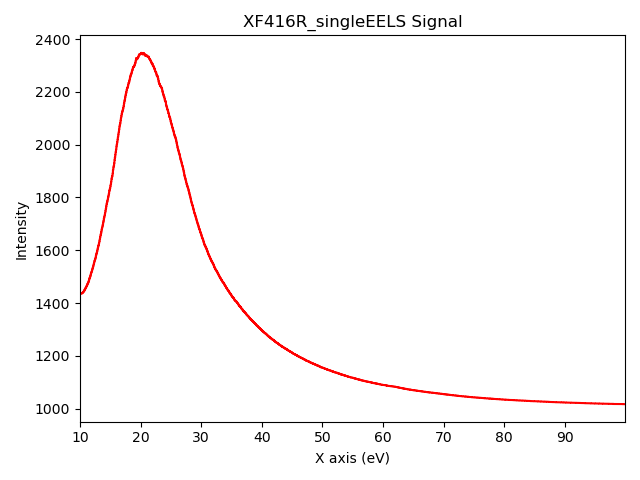

In [27]:
#cropped_data = data_corrected.isig[135.0:350.0]
cropped_data = data_corrected.isig[10.0:100.0]
cropped_data.plot()

# Save the data as a txt file

In [28]:
import numpy as np
import os

# Extract data from the HyperSpy Signal1D object
energy_axis = cropped_data.axes_manager[0].axis.copy()  # Energy loss values
core_loss_data = cropped_data.data.copy()  # Intensity values

# Stack the data into two columns (Energy Loss, Intensity)
data_to_save = np.column_stack((energy_axis, core_loss_data))

# Define the filename
filename = "low_loss_spectrum.txt"

# Save the file in the current working directory
filepath = os.path.join(os.getcwd(), filename)
np.savetxt(filepath, data_to_save, delimiter="\t", header="Energy Loss (eV)\tIntensity", comments='')

# Print the saved file path
print(f"File saved at: {filepath}")


File saved at: e:\SAXS_WAXS\TEM_analysis files\low_loss_spectrum.txt


# Remove background 

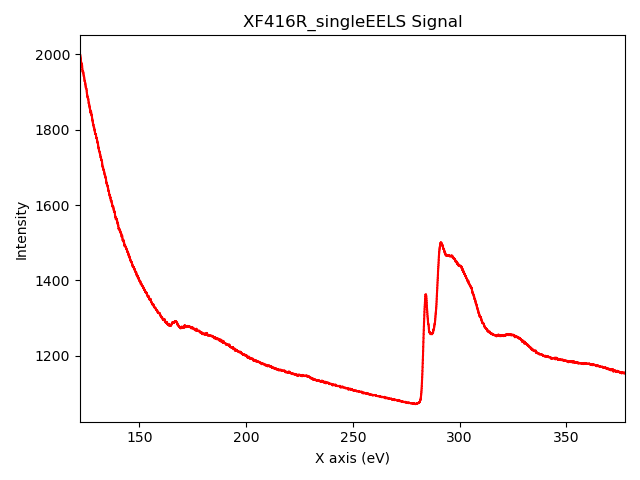

c:\Users\b1104371\AppData\Local\anaconda3\Lib\site-packages\hyperspy\signal_tools.py:1264: UserWarning: The figure layout has changed to tight
  figure.tight_layout(rect=[0, 0, 0.95, 1])
c:\Users\b1104371\AppData\Local\anaconda3\Lib\site-packages\jupyter_client\session.py:718: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


ModuleNotFoundError: No module named 'pyface.action.schema'

In [17]:

background_subtracted = data_corrected.deepcopy()
background_subtracted.plot()
background_subtracted.remove_background()


# Correction for multiple ineleastic scattering arising from thick samples 

In [ ]:
core_loss_spectra = load_file()
core_loss_spectra.set_signal_type("EELS")
low_loss_spectra = load_file()
low_loss_spectra.set_signal_type("EELS")

core_loss_spectra.plot()

In [ ]:
shift_in_eV = 2.0
aligned_core_loss_spectra = align_data(core_loss_spectra, shift_in_eV)
aligned_low_loss_spectra = align_data(low_loss_spectra, shift_in_eV)

In [ ]:
# Convert Signal1D to EELSSpectrum
aligned_core_loss_spectra.set_signal_type("EELS")
aligned_low_loss_spectra.set_signal_type("EELS")

# Now perform Richardson-Lucy deconvolution
corrected_core_loss = aligned_core_loss_spectra.richardson_lucy_deconvolution(
    psf=aligned_low_loss_spectra,
    iterations=15,
    show_progressbar=True
)

# Plot results
aligned_core_loss_spectra.plot(label="Raw Core-Loss", color="red")
corrected_core_loss.plot(label="RL-Deconvolved", color="blue")